
# Lab 6: FEM 1D

Ross Anthony Miranda D'Angelo

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

## Formulación de FEM

Para la ecuación

$$
-y''(x)=f(x),
$$

multiplicamos por una función de prueba \(\phi_i(x)\) e integramos sobre el intervalo. Tras integrar por partes:

$$
\int_a^b y'(x)\phi_i'(x)\,dx
=
\int_a^b f(x)\phi_i(x)\,dx,
$$

porque las funciones de prueba se anulan en las fronteras de Dirichlet.

Usando funciones de forma lineales a trozos,

$$
y_h(x)=\sum_j y_j\phi_j(x),
$$

obtenemos el sistema lineal

$$
\boxed{K\,Y=F}.
$$

Para un elemento \(e=[x_i,x_{i+1}]\), con

$$
h_e=x_{i+1}-x_i,
$$

las dos funciones de forma lineales son

$$
N_1(x)=\frac{x_{i+1}-x}{h_e},
\qquad
N_2(x)=\frac{x-x_i}{h_e}.
$$

Sus derivadas son

$$
N_1'=-\frac{1}{h_e},
\qquad
N_2'=\frac{1}{h_e}.
$$

Por lo tanto, la matriz de rigidez elemental es

$$
\boxed{
K^{(e)}
=
\frac{1}{h_e}
\begin{pmatrix}
1 & -1\\
-1 & 1
\end{pmatrix}
}.
$$

El vector de carga elemental se obtiene numéricamente:

$$
\boxed{
F^{(e)}
=
\begin{pmatrix}
\displaystyle\int_{x_i}^{x_{i+1}} f(x)N_1(x)\,dx\\[6pt]
\displaystyle\int_{x_i}^{x_{i+1}} f(x)N_2(x)\,dx
\end{pmatrix}
}.
$$

Las matrices y vectores elementales se ensamblan luego en las globales \(K\) y \(F\).

In [19]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt


## Función general de FEM 1D

La función siguiente funciona para cualquier intervalo \([a,b]\), cualquier función fuente \(f(x)\), cualquier valor de Dirichlet \(y(a)\) y \(y(b)\), y cualquier número de elementos.

Aquí, `N` significa el **número de elementos**, por lo que el número de nodos es `N + 1`.


In [20]:
def fem_1d(f, a, b, y_a, y_b, N):
    # Resolver -y''(x) = f(x) en [a,b]
    # con y(a)=y_a y y(b)=y_b usando FEm lineal.

    # Malla: N elementos -> N+1 nodos
    x = np.linspace(a, b, N + 1)

    # Matriz y vector globales
    K = np.zeros((N + 1, N + 1), dtype=float)
    F = np.zeros(N + 1, dtype=float)

    # Ensamblaje elemento por elemento
    for e in range(N):
        x1 = x[e]
        x2 = x[e + 1]
        h_e = x2 - x1

        # Matriz de rigidez elemental
        K_e = (1.0 / h_e) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0]
        ])

        # Funciones de forma lineales
        N1 = lambda z: (x2 - z) / h_e
        N2 = lambda z: (z - x1) / h_e

        # Vector de carga elemental
        F_e = np.array([
            integrate.quad(lambda z: f(z) * N1(z), x1, x2)[0],
            integrate.quad(lambda z: f(z) * N2(z), x1, x2)[0]
        ])

        # Ensamblaje global
        nodes = [e, e + 1]
        K[np.ix_(nodes, nodes)] += K_e
        F[nodes] += F_e

    # Condiciones de Dirichlet
    y = np.zeros(N + 1, dtype=float)
    y[0] = y_a
    y[-1] = y_b

    # Resolver solo para los nodos interiores
    free = np.arange(1, N)
    K_ff = K[np.ix_(free, free)]
    F_f = F[free] - K[free, 0] * y_a - K[free, -1] * y_b

    y[free] = np.linalg.solve(K_ff, F_f)

    return x, y, K, F

## Parámetros del problema

Para este laboratorio,

$$
f(x)=xe^x,\qquad a=0,\qquad b=1,
$$

y

$$
y_a=3-e,\qquad y_b=0.
$$

In [21]:
# Problem
f = lambda x: x * np.exp(x)

a = 0.0
b = 1.0

y_a = 3.0 - np.e
y_b = 0.0

print("a =", a)
print("b =", b)
print("y(a) =", y_a)
print("y(b) =", y_b)


a = 0.0
b = 1.0
y(a) = 0.2817181715409549
y(b) = 0.0


## Ejemplo aritmético: 5 elementos

Para \(N=5\) elementos,

$$
h=\frac{b-a}{N}=\frac{1}{5}=0.2.
$$

Por lo tanto,

$$
K^{(e)}
=
\frac{1}{0.2}
\begin{pmatrix}
1 & -1\\
-1 & 1
\end{pmatrix}
=
\begin{pmatrix}
5 & -5\\
-5 & 5
\end{pmatrix}.
$$

El vector de carga de cada elemento se calcula con `quad`, usando las dos funciones de forma lineales. El código imprime el primer vector de carga elemental y el sistema global ensamblado.

In [22]:
# Un elemento explícito para mostrar la aritmética
N_demo = 5
x_demo = np.linspace(a, b, N_demo + 1)

x1 = x_demo[0]
x2 = x_demo[1]
h_demo = x2 - x1

K_e_demo = (1.0 / h_demo) * np.array([
    [1.0, -1.0],
    [-1.0, 1.0]
])

N1_demo = lambda z: (x2 - z) / h_demo
N2_demo = lambda z: (z - x1) / h_demo

F_e_demo = np.array([
    integrate.quad(lambda z: f(z) * N1_demo(z), x1, x2)[0],
    integrate.quad(lambda z: f(z) * N2_demo(z), x1, x2)[0]
])

print("Nodos:")
print(x_demo)

print("\nTamaño del elemento h =", h_demo)

print("\nMatriz de rigidez elemental K_e:")
print(K_e_demo)

print("\nPrimer vector de carga elemental F_e:")
print(F_e_demo)

x, y_fem, K_global, F_global = fem_1d(f, a, b, y_a, y_b, N_demo)

print("\nMatriz de rigidez global K (antes de las condiciones de frontera):")
print(K_global)

print("\nVector de carga global F (antes de las condiciones de frontera):")
print(F_global)

print("\nSolución de FEM en los nodos:")
print(y_fem)


Nodos:
[0.  0.2 0.4 0.6 0.8 1. ]

Tamaño del elemento h = 0.2

Matriz de rigidez elemental K_e:
[[ 5. -5.]
 [-5.  5.]]

Primer vector de carga elemental F_e:
[0.00737518 0.01550262]

Matriz de rigidez global K (antes de las condiciones de frontera):
[[ 5. -5.  0.  0.  0.  0.]
 [-5. 10. -5.  0.  0.  0.]
 [ 0. -5. 10. -5.  0.  0.]
 [ 0.  0. -5. 10. -5.  0.]
 [ 0.  0.  0. -5. 10. -5.]
 [ 0.  0.  0.  0. -5.  5.]]

Vector de carga global F (antes de las condiciones de frontera):
[0.00737518 0.05065207 0.12173874 0.22182005 0.3602504  0.23816357]

Solución de FEM en los nodos:
[0.28171817 0.28024314 0.26863769 0.23268449 0.15236729 0.        ]


## Solución analítica

La solución analítica proporcionada en el laboratorio es

$$
y(x)=1-e-e^x(x-2)-x.
$$

La usamos para comparar con los valores del FEM en los nodos.


In [28]:
def y_exact(x):
    return 1.0 - np.e - np.exp(x) * (x - 2.0) - x


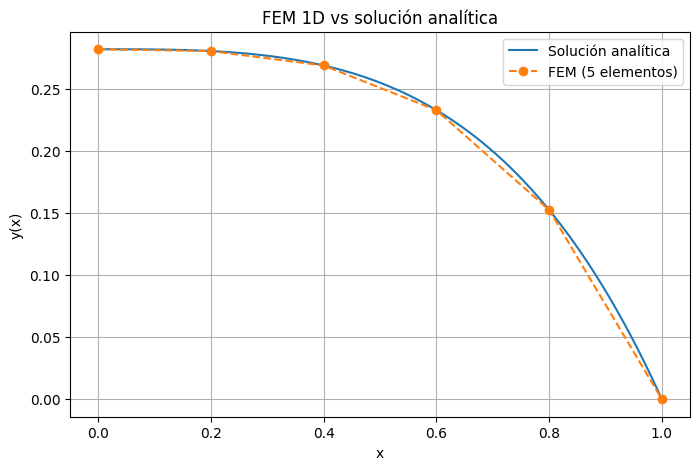

In [29]:
# Comparar N=5 elements
x_fine = np.linspace(a, b, 400)

plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_exact(x_fine), label="Solución analítica")
plt.plot(x, y_fem, "o--", label="FEM (5 elementos)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("FEM 1D vs solución analítica")
plt.grid(True)
plt.legend()
plt.show()


## Comparación para diferentes números de elementos

Ahora repetimos el cálculo para varias mallas.

La aproximación se acerca más a la solución analítica a medida que aumenta el número de elementos.


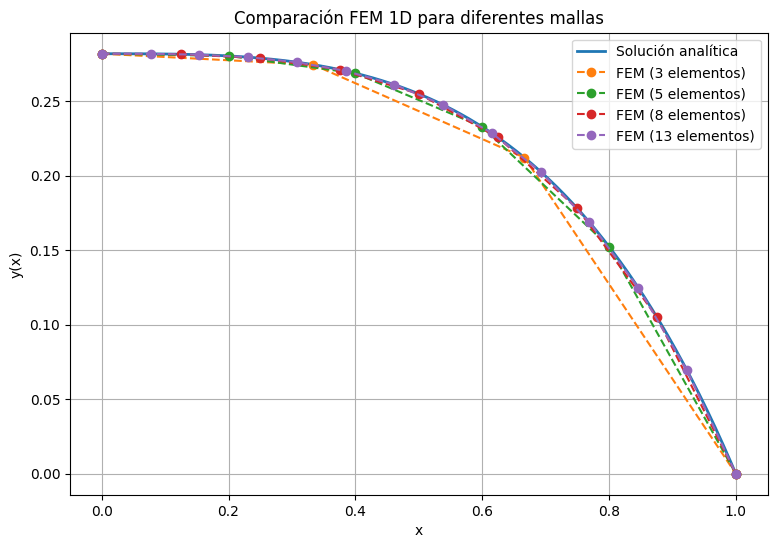

In [30]:
# Número de elementos a comparar
N_values = [3, 5, 8, 13]

x_fine = np.linspace(a, b, 400)

plt.figure(figsize=(9, 6))
plt.plot(x_fine, y_exact(x_fine), linewidth=2, label="Solución analítica")

errors = []

for N in N_values:
    x_nodes, y_nodes, _, _ = fem_1d(f, a, b, y_a, y_b, N)

    # Interpolación de MEF lineal a trozos
    y_interp = np.interp(x_fine, x_nodes, y_nodes)

    # Error máximo en la malla fina
    error_max = np.max(np.abs(y_interp - y_exact(x_fine)))
    errors.append(error_max)

    plt.plot(
        x_nodes,
        y_nodes,
        "o--",
        label=f"FEM ({N} elementos)"
    )

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Comparación FEM 1D para diferentes mallas")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
# Error table
print(f"{'Elementos':>10} {'Nodos':>8} {'Error máximo':>18}")
print("-" * 40)

for N, err in zip(N_values, errors):
    print(f"{N:10d} {N+1:8d} {err:18.6e}")


 Elementos    Nodos       Error máximo
----------------------------------------
         3        4       2.693954e-02
         5        6       1.110990e-02
         8        9       4.681484e-03
        13       14       1.861148e-03


## Conclusión

La solución por elementos finitos se obtiene ensamblando las matrices de rigidez elementales

$$
K^{(e)}
=
\frac{1}{h_e}
\begin{pmatrix}
1 & -1\\
-1 & 1
\end{pmatrix}
$$

y los vectores de carga elementales

$$
F^{(e)}
=
\begin{pmatrix}
\displaystyle\int fN_1\,dx\\
\displaystyle\int fN_2\,dx
\end{pmatrix},
$$

seguido de la aplicación de las condiciones de Dirichlet.

Para este problema, al aumentar el número de elementos, la solución de FEMlineal a trozos se aproxima a la solución analítica

$$
\boxed{y(x)=1-e-e^x(x-2)-x}.
$$